# Kalshi Weather Trading Project Walkthrough

This notebook is designed as the visual basis for a video presentation. It walks through the project goal, codebase, data pipeline, feature engineering, calculus behind bucket probabilities, model outputs, evaluation, UML/pseudocode, execution commands, and final output interpretation.

The project estimates probabilities for Kalshi-style NYC high-temperature bucket markets. The model predicts a distribution for the NWS-reported final daily high temperature by modeling the distribution of forecast error around the forecast high.

Key idea: market prices imply probabilities, and this project compares model probabilities to market-implied probabilities. Calculus is central because each bucket probability is an area under a probability density curve.

## 0. Notebook Setup

These cells keep the notebook runnable from either the repository root or the `notebooks/` folder. The notebook uses saved outputs by default, so it is fast enough for presentation use.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.stats import laplace, norm, t as student_t

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError("Run this notebook from the repo root or from notebooks/.")

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

print(f"Repository root: {REPO_ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR.relative_to(REPO_ROOT)}")

Repository root: C:\Weather Trading\Kalshi-Weather-Trading
Figures will be saved to: outputs\figures


## 1. Project Purpose and Goal

The project estimates probabilities for Kalshi-style NYC high-temperature bucket markets.

The target is not simply a single point prediction. The model predicts the distribution of the NWS-reported final daily high temperature by learning the conditional distribution of forecast error:

```text
forecast_error = actual_high - forecast_high
```

This matters because market prices imply probabilities. If a market contract trades at a price that implies probability `q_i`, and the model estimates probability `p_i`, then the first-pass edge is:

```text
EV_i = p_i - q_i
```

Calculus is the core link between the distribution model and the bucket market. For a bucket interval from `a_i` to `b_i`, the probability is the area under the density curve:

$$P(B_i) = \int_{a_i}^{b_i} f(t)\,dt$$

Using the cumulative distribution function, that same probability is:

$$P(B_i) = F(b_i) - F(a_i)$$

## 2. Codebase Overview

The repo is organized as a probability-modeling pipeline. Data is cleaned and converted into supervised forecast-error rows, timestamp-safe features are built, a distributional NGBoost model is trained, and bucket probabilities are computed from CDF differences.

In [2]:
repo_sections = [
    {"path": "data/raw/", "role": "Raw daily/hourly weather inputs", "connection": "Input source for cleaned weather tables."},
    {"path": "data/processed/", "role": "Cleaned modeling tables", "connection": "Feeds feature generation, training, and notebook demos."},
    {"path": "src/", "role": "Reusable project logic", "connection": "Functions used by scripts, tests, and notebooks."},
    {"path": "scripts/", "role": "Command-line workflows", "connection": "Rebuilds features, model comparisons, evaluation, and calibration."},
    {"path": "models/", "role": "Trained model artifacts", "connection": "Stores NGBoost model bundles and calibration config."},
    {"path": "outputs/", "role": "Generated reports and predictions", "connection": "Stores distribution params, bucket probabilities, metrics, and figures."},
    {"path": "notebooks/", "role": "Interactive walkthroughs", "connection": "Presentation and analysis notebooks."},
    {"path": "tests/", "role": "Regression and validation tests", "connection": "Checks pricing, features, calibration, and evaluation behavior."},
]
display(pd.DataFrame(repo_sections))

,path,role,connection
0,data/raw/,Raw daily/hourly weather inputs,Input source for cleaned weather tables.
1,data/processed/,Cleaned modeling tables,"Feeds feature generation, training, and notebo..."
2,src/,Reusable project logic,"Functions used by scripts, tests, and notebooks."
3,scripts/,Command-line workflows,"Rebuilds features, model comparisons, evaluati..."
4,models/,Trained model artifacts,Stores NGBoost model bundles and calibration c...
5,outputs/,Generated reports and predictions,"Stores distribution params, bucket probabiliti..."
6,notebooks/,Interactive walkthroughs,Presentation and analysis notebooks.
7,tests/,Regression and validation tests,"Checks pricing, features, calibration, and eva..."


In [3]:
module_table = pd.DataFrame([
    {
        "file/module": "src/features.py",
        "purpose": "Build timestamp-safe modeling features from target rows, observations, and forecasts.",
        "key functions/classes": "load_inputs, build_feature_matrix, get_all_model_features",
        "where used": "scripts/build_features.py, training scripts, notebook validation",
    },
    {
        "file/module": "src/leakage_checks.py",
        "purpose": "Check target leakage, future timestamps, chronological validity, and feature reproducibility.",
        "key functions/classes": "run_leakage_checks, write_leakage_report",
        "where used": "scripts/build_features.py",
    },
    {
        "file/module": "src/splits.py",
        "purpose": "Create chronological train/validation/test splits.",
        "key functions/classes": "chronological_train_validation_test_split",
        "where used": "src/train_ngboost.py, scripts/evaluate_ngboost.py",
    },
    {
        "file/module": "src/train_ngboost.py",
        "purpose": "Train the configured NGBoost distribution model and save prediction parameters.",
        "key functions/classes": "run_standard_training, build_prediction_frame, build_metrics",
        "where used": "python -m src.train_ngboost",
    },
    {
        "file/module": "src/distributional_model.py",
        "purpose": "Wrap distribution training, CDF/PDF scoring, and NGBoost prediction details.",
        "key functions/classes": "train_ngboost_distribution, distribution_cdf, distribution_nll",
        "where used": "training, evaluation, calibration, bucket pricing",
    },
    {
        "file/module": "src/distribution_pricing.py",
        "purpose": "Convert final-temperature buckets into forecast-error intervals and compute bucket probabilities.",
        "key functions/classes": "price_buckets_for_dataframe, interval_probability_from_cdf, validate_bucket_probabilities",
        "where used": "python -m src.distribution_pricing, evaluation, notebook demo",
    },
    {
        "file/module": "src/evaluation.py",
        "purpose": "Evaluate probability quality and interval coverage.",
        "key functions/classes": "negative_log_likelihood, bucket_brier_scores, prediction_interval_coverage",
        "where used": "scripts/evaluate_ngboost.py, calibration scripts",
    },
    {
        "file/module": "src/calibration.py",
        "purpose": "Build reliability tables and calibration plots.",
        "key functions/classes": "plot_pit_histogram, calibration_tables_by_bucket, fit_global_sigma_scale",
        "where used": "scripts/evaluate_ngboost.py, scripts/calibrate_ngboost.py",
    },
])
display(module_table)

,file/module,purpose,key functions/classes,where used
0,src/features.py,Build timestamp-safe modeling features from ta...,"load_inputs, build_feature_matrix, get_all_mod...","scripts/build_features.py, training scripts, n..."
1,src/leakage_checks.py,"Check target leakage, future timestamps, chron...","run_leakage_checks, write_leakage_report",scripts/build_features.py
2,src/splits.py,Create chronological train/validation/test spl...,chronological_train_validation_test_split,"src/train_ngboost.py, scripts/evaluate_ngboost.py"
3,src/train_ngboost.py,Train the configured NGBoost distribution mode...,"run_standard_training, build_prediction_frame,...",python -m src.train_ngboost
4,src/distributional_model.py,"Wrap distribution training, CDF/PDF scoring, a...","train_ngboost_distribution, distribution_cdf, ...","training, evaluation, calibration, bucket pricing"
5,src/distribution_pricing.py,Convert final-temperature buckets into forecas...,"price_buckets_for_dataframe, interval_probabil...","python -m src.distribution_pricing, evaluation..."
6,src/evaluation.py,Evaluate probability quality and interval cove...,"negative_log_likelihood, bucket_brier_scores, ...","scripts/evaluate_ngboost.py, calibration scripts"
7,src/calibration.py,Build reliability tables and calibration plots.,"plot_pit_histogram, calibration_tables_by_buck...","scripts/evaluate_ngboost.py, scripts/calibrate..."


## 3. Data Pipeline

The project uses cleaned observation data, cleaned forecast data, supervised forecast-error rows, and final modeling rows. Each supervised row represents a prediction timestamp for a target date.

Important columns:

- `actual_high`: realized final daily high temperature.
- `forecast_high`: forecast high available to the model.
- `forecast_error`: target, equal to `actual_high - forecast_high`.
- `prediction_time`: timestamp at which the model is making the prediction.
- `current_temp`, `max_temp_so_far`, and other path features: only use observations available at or before `prediction_time`.
- Market prices: no timestamp-correct market-price table is currently present in this repo, so the trading section uses an illustrative market-price example.

In [4]:
key_tables = {
    "supervised rows": "data/processed/supervised_forecast_error_rows.csv",
    "modeling rows": "data/processed/modeling_rows_v1.csv",
    "hourly observations": "data/processed/hourly_clean.csv",
    "hourly forecasts": "data/processed/hourly_forecasts_clean.csv",
    "daily observations": "data/processed/daily_clean.csv",
    "daily forecasts": "data/processed/forecasts_clean.csv",
    "distribution params": "outputs/ngboost_distribution_params_v0.csv",
    "bucket probabilities": "outputs/ngboost_bucket_probs_v0.csv",
}

inventory = []
for label, rel in key_tables.items():
    path = REPO_ROOT / rel
    if path.exists():
        preview = pd.read_csv(path, nrows=3)
        row_count = sum(1 for _ in path.open("r", encoding="utf-8", errors="ignore")) - 1
        inventory.append({"table": label, "path": rel, "rows": row_count, "columns": len(preview.columns)})
    else:
        inventory.append({"table": label, "path": rel, "rows": None, "columns": None})

display(pd.DataFrame(inventory))

,table,path,rows,columns
0,supervised rows,data/processed/supervised_forecast_error_rows.csv,38424,8
1,modeling rows,data/processed/modeling_rows_v1.csv,38424,55
2,hourly observations,data/processed/hourly_clean.csv,38424,21
3,hourly forecasts,data/processed/hourly_forecasts_clean.csv,38424,22
4,daily observations,data/processed/daily_clean.csv,1601,18
5,daily forecasts,data/processed/forecasts_clean.csv,1601,20
6,distribution params,outputs/ngboost_distribution_params_v0.csv,20904,17
7,bucket probabilities,outputs/ngboost_bucket_probs_v0.csv,125424,23


In [5]:
modeling = pd.read_csv(REPO_ROOT / "data/processed/modeling_rows_v1.csv")
hourly = pd.read_csv(REPO_ROOT / "data/processed/hourly_clean.csv")
hourly_forecasts = pd.read_csv(REPO_ROOT / "data/processed/hourly_forecasts_clean.csv")
params = pd.read_csv(REPO_ROOT / "outputs/ngboost_distribution_params_v0.csv")
bucket_probs = pd.read_csv(REPO_ROOT / "outputs/ngboost_bucket_probs_v0.csv")

print("Modeling rows sample")
display(modeling.head(5))
print("Bucket probability sample")
display(bucket_probs.head(8))

Modeling rows sample


,date,location,prediction_time,prediction_timestamp,actual_high,forecast_high,forecast_error,forecast_source,target_date,prediction_clock_time,day_of_year_sin,day_of_year_cos,hour_sin,hour_cos,month,season,forecast_horizon_hours,current_temp,dew_point,cloud_cover_now,wind_speed,precipitation_now,current_temp_source_time,temp_minus_dew_point,wind_dir_sin,wind_dir_cos,max_temp_so_far,max_temp_so_far_source_time,temp_change_30m,temp_change_60m,temp_change_120m,temp_change_180m,temp_change_240m,temp_change_300m,temp_acceleration_60m,temp_change_60m_minus_3h_avg_rate,forecast_temp_current_hour,current_temp_minus_forecast_temp,forecast_max_so_far,max_so_far_minus_forecast_max_so_far,cloud_cover_next_3h,precip_probability_next_3h,forecast_temp_source_valid_time,forecast_max_so_far_source_valid_time,current_temp_minus_max_so_far,minutes_since_max_temp_so_far,hour_of_max_temp_so_far,max_so_far_minus_forecast_high,mean_temp_error_so_far,max_temp_error_so_far,num_new_highs_last_3h,temp_range_so_far,area_under_temp_curve_so_far,near_boundary_duration_so_far,minutes_until_typical_peak
0,2022-01-01,NYC,2022-01-01 00:00:00,2022-01-01 00:00:00,53.3,54.3,-1.0,open_meteo_historical_forecast,2022-01-01,00:00,0.017166,0.999853,0.000000,1.000000,1,0.0,15.0,46.2,46.1,100.0,2.1,0.000,2022-01-01 00:00:00,0.1,0.529919,-0.848048,46.2,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.8,-3.6,49.8,-3.6,NaN,NaN,2022-01-01 00:00:00,2022-01-01 00:00:00,0.0,0.0,0.0,-8.1,-3.600000,-3.6,1.0,0.0,0.00,1.0,900.0
1,2022-01-01,NYC,2022-01-01 01:00:00,2022-01-01 01:00:00,53.3,54.3,-1.0,open_meteo_historical_forecast,2022-01-01,01:00,0.017166,0.999853,0.258819,0.965926,1,0.0,14.0,46.2,46.1,100.0,4.0,0.000,2022-01-01 01:00:00,0.1,0.275637,-0.961262,46.2,2022-01-01 01:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,49.8,-3.6,49.8,-3.6,NaN,NaN,2022-01-01 01:00:00,2022-01-01 01:00:00,0.0,0.0,1.0,-8.1,-3.600000,-3.6,1.0,0.0,46.20,2.0,840.0
2,2022-01-01,NYC,2022-01-01 02:00:00,2022-01-01 02:00:00,53.3,54.3,-1.0,open_meteo_historical_forecast,2022-01-01,02:00,0.017166,0.999853,0.500000,0.866025,1,0.0,13.0,46.6,46.5,100.0,2.9,0.000,2022-01-01 02:00:00,0.1,0.529919,-0.848048,46.6,2022-01-01 02:00:00,NaN,0.4,0.4,NaN,NaN,NaN,0.4,NaN,50.0,-3.4,50.0,-3.4,NaN,NaN,2022-01-01 02:00:00,2022-01-01 02:00:00,0.0,0.0,2.0,-7.7,-3.533333,-3.4,2.0,0.4,92.60,3.0,780.0
3,2022-01-01,NYC,2022-01-01 03:00:00,2022-01-01 03:00:00,53.3,54.3,-1.0,open_meteo_historical_forecast,2022-01-01,03:00,0.017166,0.999853,0.707107,0.707107,1,0.0,12.0,46.1,46.0,100.0,4.6,0.000,2022-01-01 03:00:00,0.1,0.731354,-0.681998,46.6,2022-01-01 02:00:00,NaN,-0.5,-0.1,-0.1,NaN,NaN,-0.9,-0.466667,49.7,-3.6,50.0,-3.4,NaN,NaN,2022-01-01 03:00:00,2022-01-01 02:00:00,-0.5,60.0,2.0,-7.7,-3.550000,-3.4,1.0,0.5,138.95,4.0,720.0
4,2022-01-01,NYC,2022-01-01 04:00:00,2022-01-01 04:00:00,53.3,54.3,-1.0,open_meteo_historical_forecast,2022-01-01,04:00,0.017166,0.999853,0.866025,0.500000,1,0.0,11.0,45.8,45.7,100.0,2.9,0.004,2022-01-01 04:00:00,0.1,0.987688,-0.156434,46.6,2022-01-01 02:00:00,NaN,-0.3,-0.8,-0.4,-0.4,NaN,0.2,-0.166667,49.8,-4.0,50.0,-3.4,NaN,NaN,2022-01-01 04:00:00,2022-01-01 02:00:00,-0.8,120.0,2.0,-7.7,-3.640000,-3.4,1.0,0.8,184.90,5.0,660.0


Bucket probability sample


,row_id,date,prediction_time,location,split,forecast_high,actual_high,forecast_error,bucket_index,bucket_name,bucket_lower_temp,bucket_upper_temp,error_lower,error_upper,mu,sigma,distribution_type,df,probability,timestamp,prediction_timestamp,forecast_horizon_hours,nll
0,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,0,42 or lower,NaN,42.5,NaN,-3.5,-1.513328,1.642242,laplace,NaN,0.149139,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
1,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,1,43 to 44,42.5,44.5,-3.5,-1.5,-1.513328,1.642242,laplace,NaN,0.354903,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
2,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,2,45 to 46,44.5,46.5,-1.5,0.5,-1.513328,1.642242,laplace,NaN,0.349221,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
3,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,3,47 to 48,46.5,48.5,0.5,2.5,-1.513328,1.642242,laplace,NaN,0.103323,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
4,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,4,49 to 50,48.5,50.5,2.5,4.5,-1.513328,1.642242,laplace,NaN,0.030570,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
5,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,5,51 or higher,50.5,NaN,4.5,NaN,-1.513328,1.642242,laplace,NaN,0.012845,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
6,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,0,42 or lower,NaN,42.5,NaN,-3.5,-1.670108,1.642242,laplace,NaN,0.164078,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824
7,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,1,43 to 44,42.5,44.5,-3.5,-1.5,-1.670108,1.642242,laplace,NaN,0.385121,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824


### Data Validation Checks

The checks below are lightweight notebook checks for presentation. The full feature build also writes `outputs/day8_features/leakage_check_report.md`.

In [6]:
with open(REPO_ROOT / "outputs/final_feature_list.json", "r", encoding="utf-8") as f:
    feature_payload = json.load(f)
final_features = feature_payload.get("features", feature_payload if isinstance(feature_payload, list) else [])

working = modeling.copy()
working["date"] = pd.to_datetime(working["date"], errors="coerce")
working["target_date"] = pd.to_datetime(working["target_date"], errors="coerce")
working["prediction_time"] = pd.to_datetime(working["prediction_time"], errors="coerce")

critical_cols = ["date", "target_date", "prediction_time", "actual_high", "forecast_high", "forecast_error"]
source_time_cols = [
    "current_temp_source_time",
    "max_temp_so_far_source_time",
    "forecast_temp_source_valid_time",
    "forecast_max_so_far_source_valid_time",
]

validation_rows = []
validation_rows.append({"check": "row count", "result": len(working), "status": "PASS" if len(working) > 0 else "FAIL"})
validation_rows.append({"check": "date range", "result": f"{working['date'].min().date()} to {working['date'].max().date()}", "status": "PASS"})
missing_critical = int(working[critical_cols].isna().sum().sum())
validation_rows.append({"check": "missing critical values", "result": missing_critical, "status": "PASS" if missing_critical == 0 else "WARN"})

parse_bad = working[["date", "target_date", "prediction_time"]].isna().any(axis=1)
future_window = working["prediction_time"] >= (working["target_date"] + pd.Timedelta(days=1))
bad_window = int((parse_bad | future_window).sum())
validation_rows.append({"check": "prediction_time inside target-date window", "result": bad_window, "status": "PASS" if bad_window == 0 else "FAIL"})

future_source_violations = 0
for col in source_time_cols:
    if col in working.columns:
        source_time = pd.to_datetime(working[col], errors="coerce")
        future_source_violations += int((source_time.notna() & (source_time > working["prediction_time"])).sum())
validation_rows.append({
    "check": "source timestamps at or before prediction_time",
    "result": future_source_violations,
    "status": "PASS" if future_source_violations == 0 else "FAIL",
})

forbidden = {"actual_high", "forecast_error", "target", "final_high", "official_high", "settlement_bucket"}
overlap = sorted(forbidden.intersection(set(final_features)))
validation_rows.append({
    "check": "no target/final outcome columns in final feature list",
    "result": ", ".join(overlap) if overlap else "none",
    "status": "PASS" if not overlap else "FAIL",
})

duplicate_keys = int(working.duplicated(["location", "target_date", "prediction_time"]).sum())
validation_rows.append({"check": "duplicate location/date/prediction_time rows", "result": duplicate_keys, "status": "PASS" if duplicate_keys == 0 else "WARN"})

display(pd.DataFrame(validation_rows))

,check,result,status
0,row count,38424,PASS
1,date range,2022-01-01 to 2026-05-20,PASS
2,missing critical values,0,PASS
3,prediction_time inside target-date window,0,PASS
4,source timestamps at or before prediction_time,0,PASS
5,no target/final outcome columns in final featu...,none,PASS
6,duplicate location/date/prediction_time rows,0,PASS


## 4. Feature Engineering

Feature engineering is timestamp-safe: each row only uses information available at or before `prediction_time`.

The model includes calendar/time features, observed weather features, forecast-relative features, and intraday path-dependent features. The sequential features below describe the path of the temperature so far, not the final high after the prediction time.

In [7]:
sequential_features = [
    "current_temp_minus_max_so_far",
    "minutes_since_max_temp_so_far",
    "hour_of_max_temp_so_far",
    "max_so_far_minus_forecast_high",
    "mean_temp_error_so_far",
    "max_temp_error_so_far",
    "num_new_highs_last_3h",
    "temp_range_so_far",
    "area_under_temp_curve_so_far",
    "near_boundary_duration_so_far",
]

feature_descriptions = {
    "current_temp_minus_max_so_far": "How far the current temperature is below or above the intraday max so far.",
    "minutes_since_max_temp_so_far": "Minutes since the latest observed max-so-far timestamp.",
    "hour_of_max_temp_so_far": "Clock hour when the max-so-far occurred.",
    "max_so_far_minus_forecast_high": "Observed max so far compared with the forecast daily high.",
    "mean_temp_error_so_far": "Average observed-minus-forecast hourly temperature error so far.",
    "max_temp_error_so_far": "Max observed temperature so far compared with the forecast max so far.",
    "num_new_highs_last_3h": "Count of strict new intraday highs during the trailing 3 hours.",
    "temp_range_so_far": "Observed max minus min temperature so far today.",
    "area_under_temp_curve_so_far": "Trapezoid integral of observed temperature through prediction_time.",
    "near_boundary_duration_so_far": "Number of hourly observations near an integer-degree boundary so far.",
}

seq_table = pd.DataFrame([
    {
        "feature": feature,
        "purpose": feature_descriptions[feature],
        "in_modeling_rows": feature in modeling.columns,
        "in_final_model_features": feature in final_features,
        "missing_fraction": float(modeling[feature].isna().mean()) if feature in modeling.columns else np.nan,
    }
    for feature in sequential_features
])
display(seq_table)

,feature,purpose,in_modeling_rows,in_final_model_features,missing_fraction
0,current_temp_minus_max_so_far,How far the current temperature is below or ab...,True,True,0.0
1,minutes_since_max_temp_so_far,Minutes since the latest observed max-so-far t...,True,True,0.0
2,hour_of_max_temp_so_far,Clock hour when the max-so-far occurred.,True,True,0.0
3,max_so_far_minus_forecast_high,Observed max so far compared with the forecast...,True,True,0.0
4,mean_temp_error_so_far,Average observed-minus-forecast hourly tempera...,True,True,0.0
5,max_temp_error_so_far,Max observed temperature so far compared with ...,True,True,0.0
6,num_new_highs_last_3h,Count of strict new intraday highs during the ...,True,True,0.0
7,temp_range_so_far,Observed max minus min temperature so far today.,True,False,0.0
8,area_under_temp_curve_so_far,Trapezoid integral of observed temperature thr...,True,True,0.0
9,near_boundary_duration_so_far,Number of hourly observations near an integer-...,True,True,0.0


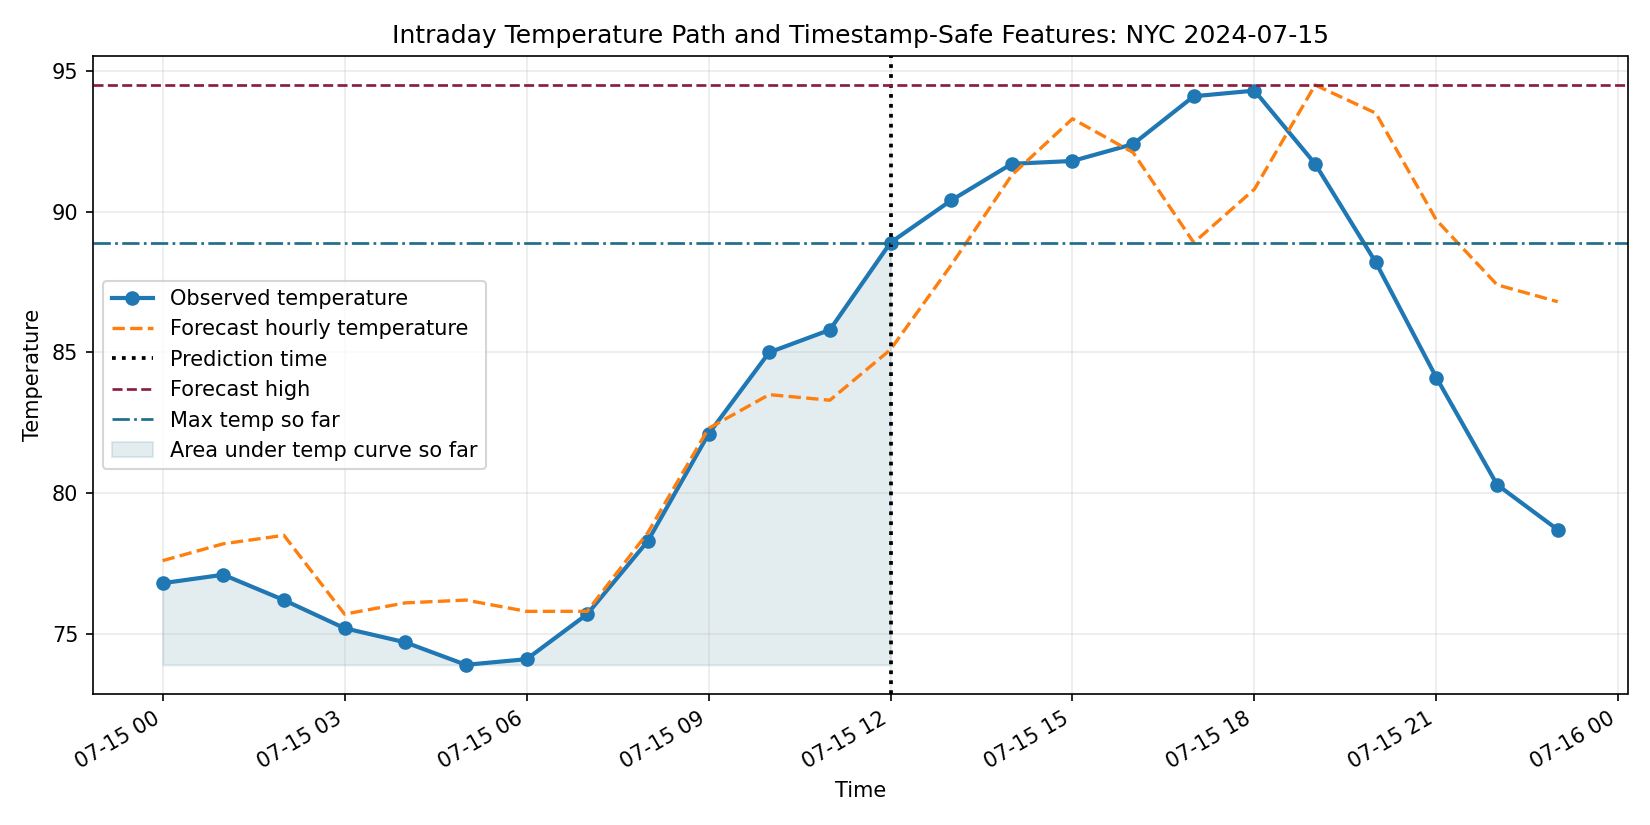

,value
prediction_time,2024-07-15 12:00:00
current_temp,88.9
max_temp_so_far,88.9
forecast_high,94.5
current_temp_minus_max_so_far,0.0
minutes_since_max_temp_so_far,0.0
max_so_far_minus_forecast_high,-5.6
mean_temp_error_so_far,-0.223077
num_new_highs_last_3h,3.0
area_under_temp_curve_so_far,940.95


In [8]:
hourly_plot = hourly.copy()
hourly_plot["timestamp"] = pd.to_datetime(hourly_plot["timestamp"], errors="coerce")
hourly_plot["date"] = pd.to_datetime(hourly_plot["date"], errors="coerce").dt.date
hourly_forecasts_plot = hourly_forecasts.copy()
hourly_forecasts_plot["timestamp"] = pd.to_datetime(hourly_forecasts_plot["timestamp"], errors="coerce")
hourly_forecasts_plot["date"] = pd.to_datetime(hourly_forecasts_plot["date"], errors="coerce").dt.date

preferred = pd.Timestamp("2024-07-15").date()
if preferred not in set(hourly_plot["date"].dropna()):
    preferred = hourly_plot["date"].dropna().iloc[len(hourly_plot["date"].dropna()) // 2]

obs_day = hourly_plot[(hourly_plot["date"] == preferred) & (hourly_plot["location"].astype(str) == "NYC")].copy()
fcst_day = hourly_forecasts_plot[(hourly_forecasts_plot["date"] == preferred) & (hourly_forecasts_plot["location"].astype(str) == "NYC")].copy()
model_day = modeling[pd.to_datetime(modeling["date"]).dt.date == preferred].copy()
model_day["prediction_time"] = pd.to_datetime(model_day["prediction_time"], errors="coerce")
example_row = model_day.iloc[(model_day["prediction_time"].dt.hour - 12).abs().argsort().iloc[0]]
prediction_time = pd.to_datetime(example_row["prediction_time"])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(obs_day["timestamp"], obs_day["temperature_2m"], marker="o", linewidth=2, label="Observed temperature")
if not fcst_day.empty and "temperature_2m" in fcst_day.columns:
    ax.plot(fcst_day["timestamp"], fcst_day["temperature_2m"], linestyle="--", linewidth=1.6, label="Forecast hourly temperature")
ax.axvline(prediction_time, color="black", linestyle=":", linewidth=1.8, label="Prediction time")
ax.axhline(float(example_row["forecast_high"]), color="#8b1e3f", linestyle="--", linewidth=1.3, label="Forecast high")
ax.axhline(float(example_row["max_temp_so_far"]), color="#1f6f8b", linestyle="-.", linewidth=1.3, label="Max temp so far")
ax.fill_between(
    obs_day["timestamp"],
    obs_day["temperature_2m"],
    obs_day["temperature_2m"].min(),
    where=obs_day["timestamp"] <= prediction_time,
    alpha=0.12,
    color="#1f6f8b",
    label="Area under temp curve so far",
)
ax.set_title(f"Intraday Temperature Path and Timestamp-Safe Features: NYC {preferred}")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()
path_plot = FIGURES_DIR / "notebook_intraday_feature_path.png"
fig.savefig(path_plot, dpi=150)
plt.close(fig)

display(Image(filename=str(path_plot)))
feature_snapshot = example_row[[
    "prediction_time",
    "current_temp",
    "max_temp_so_far",
    "forecast_high",
    "current_temp_minus_max_so_far",
    "minutes_since_max_temp_so_far",
    "max_so_far_minus_forecast_high",
    "mean_temp_error_so_far",
    "num_new_highs_last_3h",
    "area_under_temp_curve_so_far",
    "near_boundary_duration_so_far",
]].to_frame("value")
display(feature_snapshot)

## 5. Calculus and Bucket Probability

For a bucket `B_i = (a_i, b_i]`, the model probability is the integral of the density over that interval:

$$P(B_i) = \int_{a_i}^{b_i} f(t)\,dt$$

Equivalently, using the CDF:

$$P(B_i) = F(b_i) - F(a_i)$$

For trading comparison:

$$EV_i = p_i - q_i$$

where `p_i` is the model probability and `q_i` is the market-implied probability.

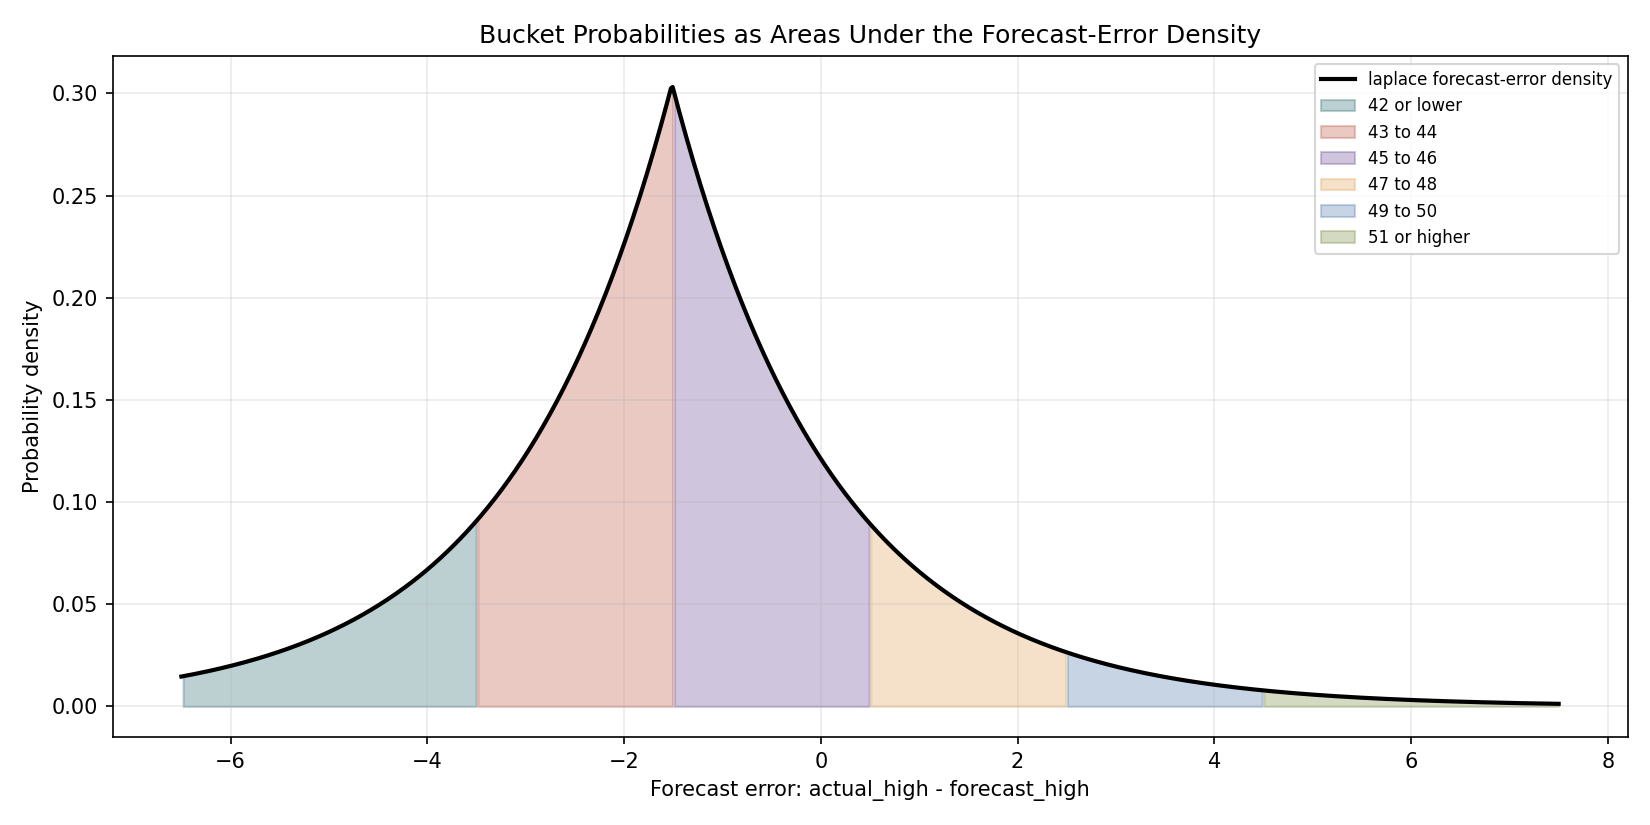

In [9]:
def pdf_for_distribution(x, mu, sigma, dist_type, df=None):
    dist = str(dist_type).lower()
    if dist in {"normal", "gaussian"}:
        return norm.pdf(x, loc=mu, scale=sigma)
    if dist in {"laplace", "laplace_distribution"}:
        return laplace.pdf(x, loc=mu, scale=sigma)
    if dist in {"student_t", "t"}:
        df_value = 5.0 if df is None or pd.isna(df) else float(df)
        return student_t.pdf((x - mu) / sigma, df=df_value) / sigma
    return norm.pdf(x, loc=mu, scale=sigma)

example_params = params.iloc[0]
row_id = int(example_params["row_id"])
example_buckets = bucket_probs[bucket_probs["row_id"] == row_id].sort_values("bucket_index").copy()
mu = float(example_params["mu"])
sigma = float(example_params["sigma"])
dist_type = str(example_params.get("distribution_type", "normal"))
df_value = example_params.get("df", np.nan)

finite_bounds = pd.concat([example_buckets["error_lower"], example_buckets["error_upper"]], ignore_index=True).dropna()
x_min = float(finite_bounds.min()) - 3.0
x_max = float(finite_bounds.max()) + 3.0
x = np.linspace(x_min, x_max, 800)
y = pdf_for_distribution(x, mu, sigma, dist_type, df=df_value)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, y, color="black", linewidth=2, label=f"{dist_type} forecast-error density")
colors = ["#2f6f73", "#c05746", "#6a4c93", "#e0a458", "#4f7cac", "#7b8c42"]
for i, (_, bucket) in enumerate(example_buckets.iterrows()):
    lower = x_min if pd.isna(bucket["error_lower"]) else float(bucket["error_lower"])
    upper = x_max if pd.isna(bucket["error_upper"]) else float(bucket["error_upper"])
    mask = (x > lower) & (x <= upper)
    ax.fill_between(x[mask], y[mask], alpha=0.32, color=colors[i % len(colors)], label=str(bucket["bucket_name"]))
ax.set_title("Bucket Probabilities as Areas Under the Forecast-Error Density")
ax.set_xlabel("Forecast error: actual_high - forecast_high")
ax.set_ylabel("Probability density")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
density_path = FIGURES_DIR / "notebook_bucket_density.png"
fig.savefig(density_path, dpi=150)
plt.close(fig)

display(Image(filename=str(density_path)))

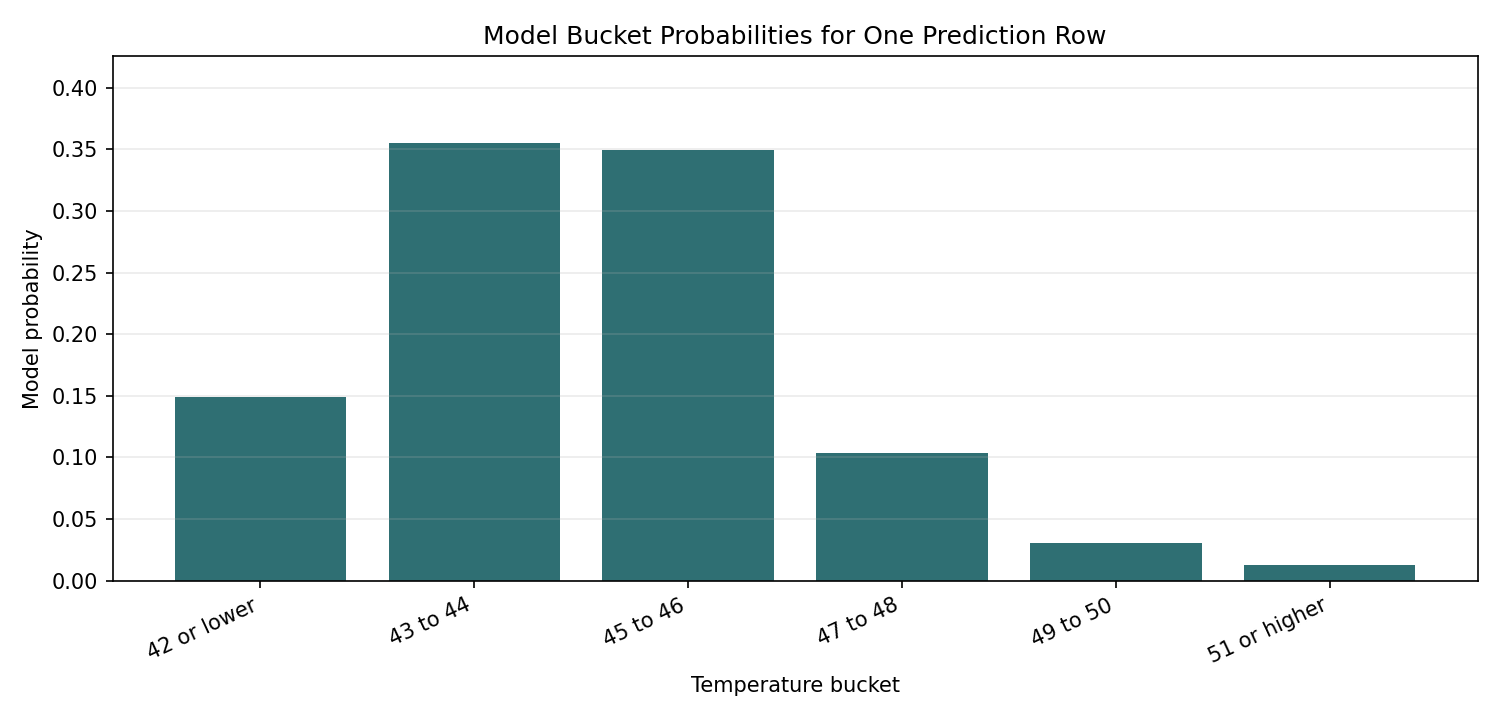

,bucket_name,error_lower,error_upper,probability
0,42 or lower,NaN,-3.5,0.149139
1,43 to 44,-3.5,-1.5,0.354903
2,45 to 46,-1.5,0.5,0.349221
3,47 to 48,0.5,2.5,0.103323
4,49 to 50,2.5,4.5,0.030570
5,51 or higher,4.5,NaN,0.012845


In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(example_buckets["bucket_name"], example_buckets["probability"], color="#2f6f73")
ax.set_title("Model Bucket Probabilities for One Prediction Row")
ax.set_xlabel("Temperature bucket")
ax.set_ylabel("Model probability")
ax.set_ylim(0, max(0.4, float(example_buckets["probability"].max()) * 1.2))
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
bar_path = FIGURES_DIR / "notebook_bucket_probabilities.png"
fig.savefig(bar_path, dpi=150)
plt.close(fig)

display(Image(filename=str(bar_path)))
display(example_buckets[["bucket_name", "error_lower", "error_upper", "probability"]])

## 6. Model Training / Prediction

The current configured model is a distribution-first NGBoost/DGBM-style model. It outputs a forecast-error distribution, not just a single forecast.

Pipeline:

```text
timestamped features -> distribution model -> final-high distribution -> bucket probabilities
```

In this repo, the configured training path saves distribution parameters to `outputs/ngboost_distribution_params_v0.csv`. Full training can take longer, so this notebook loads saved outputs by default and includes the exact training command in the execution section.

In [11]:
metrics_path = REPO_ROOT / "outputs/ngboost_nll_v0.json"
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

summary_rows = [
    {"metric": "model_name", "value": metrics.get("model_name")},
    {"metric": "distribution_type", "value": metrics.get("distribution_type")},
    {"metric": "sigma_scale", "value": metrics.get("sigma_scale")},
    {"metric": "feature_count", "value": metrics.get("feature_count")},
    {"metric": "train_rows", "value": metrics.get("train_row_count")},
    {"metric": "validation_rows", "value": metrics.get("validation_row_count")},
    {"metric": "test_rows", "value": metrics.get("test_row_count")},
    {"metric": "validation_ngboost_nll", "value": metrics.get("validation_ngboost_nll")},
    {"metric": "test_ngboost_nll", "value": metrics.get("test_ngboost_nll")},
]
display(pd.DataFrame(summary_rows))
print("First 12 final model features:")
display(pd.Series(final_features[:12], name="feature"))

,metric,value
0,model_name,ngboost_laplace_v0
1,distribution_type,laplace
2,sigma_scale,1.3
3,feature_count,36
4,train_rows,17520
5,validation_rows,8784
6,test_rows,12120
7,validation_ngboost_nll,1.193115
8,test_ngboost_nll,1.401027


First 12 final model features:


0            day_of_year_sin
1                   hour_sin
2                   hour_cos
3                      month
4                     season
5     forecast_horizon_hours
6               current_temp
7                  dew_point
8            cloud_cover_now
9                 wind_speed
10         precipitation_now
11      temp_minus_dew_point
Name: feature, dtype: object

In [12]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    import subprocess
    subprocess.run([sys.executable, "-m", "src.train_ngboost"], check=True)
else:
    print("Presentation mode: loading saved training outputs instead of retraining.")
    print("Full training command: python -m src.train_ngboost")

Presentation mode: loading saved training outputs instead of retraining.
Full training command: python -m src.train_ngboost


## 7. Calibration and Evaluation

The project evaluates probability quality, not just point error. Useful diagnostics include:

- NLL/log loss: rewards assigning high probability density to the realized forecast error.
- Brier score: squared error for bucket probabilities.
- Calibration curve: checks whether events predicted at a given probability happen at about that rate.
- Prediction interval coverage: checks whether 50%, 80%, 90%, and 95% intervals contain the realized error at the expected rate.
- PIT histogram: a well-calibrated distribution should have PIT values close to uniform.

In [13]:
eval_report = pd.read_csv(REPO_ROOT / "outputs/ngboost_evaluation_report.csv")
coverage_report = pd.read_csv(REPO_ROOT / "outputs/coverage_report.csv")
brier_report = pd.read_csv(REPO_ROOT / "outputs/bucket_brier_scores.csv")
calibration_report = pd.read_csv(REPO_ROOT / "outputs/ngboost_calibration_report.csv")

print("Evaluation report")
display(eval_report)
print("Coverage report")
display(coverage_report)
print("Bucket Brier score sample")
display(brier_report.head(8))
print("Calibration report")
display(calibration_report)

Evaluation report


,model,split,bucket_schema,n_rows,nll,interval_log_loss,mean_bucket_brier,coverage_error_50,coverage_error_80,coverage_error_90,residual_mean,residual_std
0,ngboost_laplace_v0,validation,day9_forecast_error_intervals,8784,1.193115,0.892897,0.094330,0.145492,0.11143,0.067327,0.110859,0.691948
1,ngboost_laplace_v0,test,day9_forecast_error_intervals,12120,1.401027,0.904891,0.094822,0.057096,0.07335,0.057096,-0.035911,0.843485
2,empirical_baseline_day9,test,day9_forecast_error_intervals,12120,NaN,1.488905,0.154249,NaN,NaN,NaN,NaN,NaN


Coverage report


,split,level,expected_coverage,actual_coverage,coverage_error,avg_interval_width,n
0,validation,0.5,0.5,0.645492,0.145492,1.661671,8784
1,validation,0.8,0.8,0.911430,0.111430,3.858282,8784
2,validation,0.9,0.9,0.967327,0.067327,5.519953,8784
3,test,0.5,0.5,0.557096,0.057096,1.695015,12120
4,test,0.8,0.8,0.873350,0.073350,3.935702,12120
5,test,0.9,0.9,0.957096,0.057096,5.630717,12120
6,combined_out_of_sample,0.5,0.5,0.594240,0.094240,1.681004,20904
7,combined_out_of_sample,0.8,0.8,0.889351,0.089351,3.903169,20904
8,combined_out_of_sample,0.9,0.9,0.961395,0.061395,5.584173,20904


Bucket Brier score sample


,split,bucket_schema,bucket,brier_score,mean_predicted_probability,empirical_frequency,calibration_gap,count,interval_log_loss,mean_bucket_brier
0,validation,kalshi_around_forecast_bucket_index,market_bucket_0,0.054583,0.113766,0.081967,0.031799,8784,0.927396,0.079163
1,validation,kalshi_around_forecast_bucket_index,market_bucket_1,0.123016,0.280433,0.254098,0.026335,8784,0.927396,0.079163
2,validation,kalshi_around_forecast_bucket_index,market_bucket_2,0.159210,0.387519,0.418033,-0.030514,8784,0.927396,0.079163
3,validation,kalshi_around_forecast_bucket_index,market_bucket_3,0.093156,0.150883,0.180328,-0.029445,8784,0.927396,0.079163
4,validation,kalshi_around_forecast_bucket_index,market_bucket_4,0.032772,0.050122,0.049180,0.000942,8784,0.927396,0.079163
5,validation,kalshi_around_forecast_bucket_index,market_bucket_5,0.012240,0.017277,0.016393,0.000884,8784,0.927396,0.079163
6,test,kalshi_around_forecast_bucket_index,market_bucket_0,0.091897,0.124707,0.166337,-0.041630,12120,0.992154,0.085270
7,test,kalshi_around_forecast_bucket_index,market_bucket_1,0.138901,0.285622,0.279208,0.006414,12120,0.992154,0.085270


Calibration report


,method,alpha,split,nll,bucket_brier,bucket_log_loss,coverage_50,coverage_80,coverage_90,coverage_95,coverage_gap_50,coverage_gap_80,coverage_gap_90,coverage_gap_95,mean_sigma,median_sigma
0,raw_ngboost,1.0,validation,1.193115,0.079163,0.927396,0.645492,0.911430,0.967327,0.988502,0.145492,0.111430,0.067327,0.038502,1.198643,1.579122
1,raw_ngboost,1.0,test,1.401027,0.085270,0.992154,0.557096,0.873350,0.957096,0.983168,0.057096,0.073350,0.057096,0.033168,1.222695,1.560319
2,global_sigma_scaled,0.7,validation,1.127593,0.079130,0.918920,0.513206,0.815232,0.912113,0.954349,0.013206,0.015232,0.012113,0.004349,0.839050,1.105385
3,global_sigma_scaled,0.7,test,1.394728,0.088398,1.020891,0.431848,0.744059,0.873845,0.939769,-0.068152,-0.055941,-0.026155,-0.010231,0.855886,1.092223


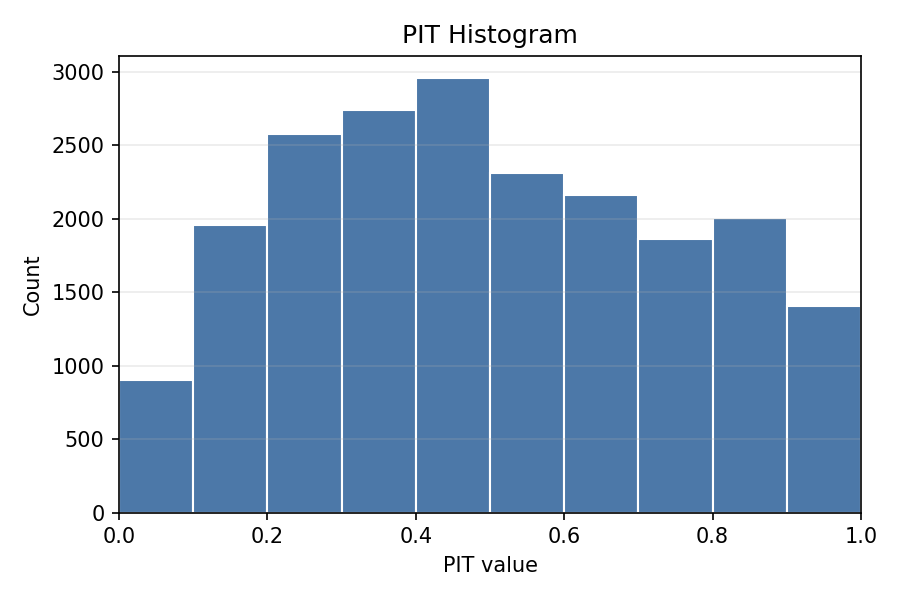

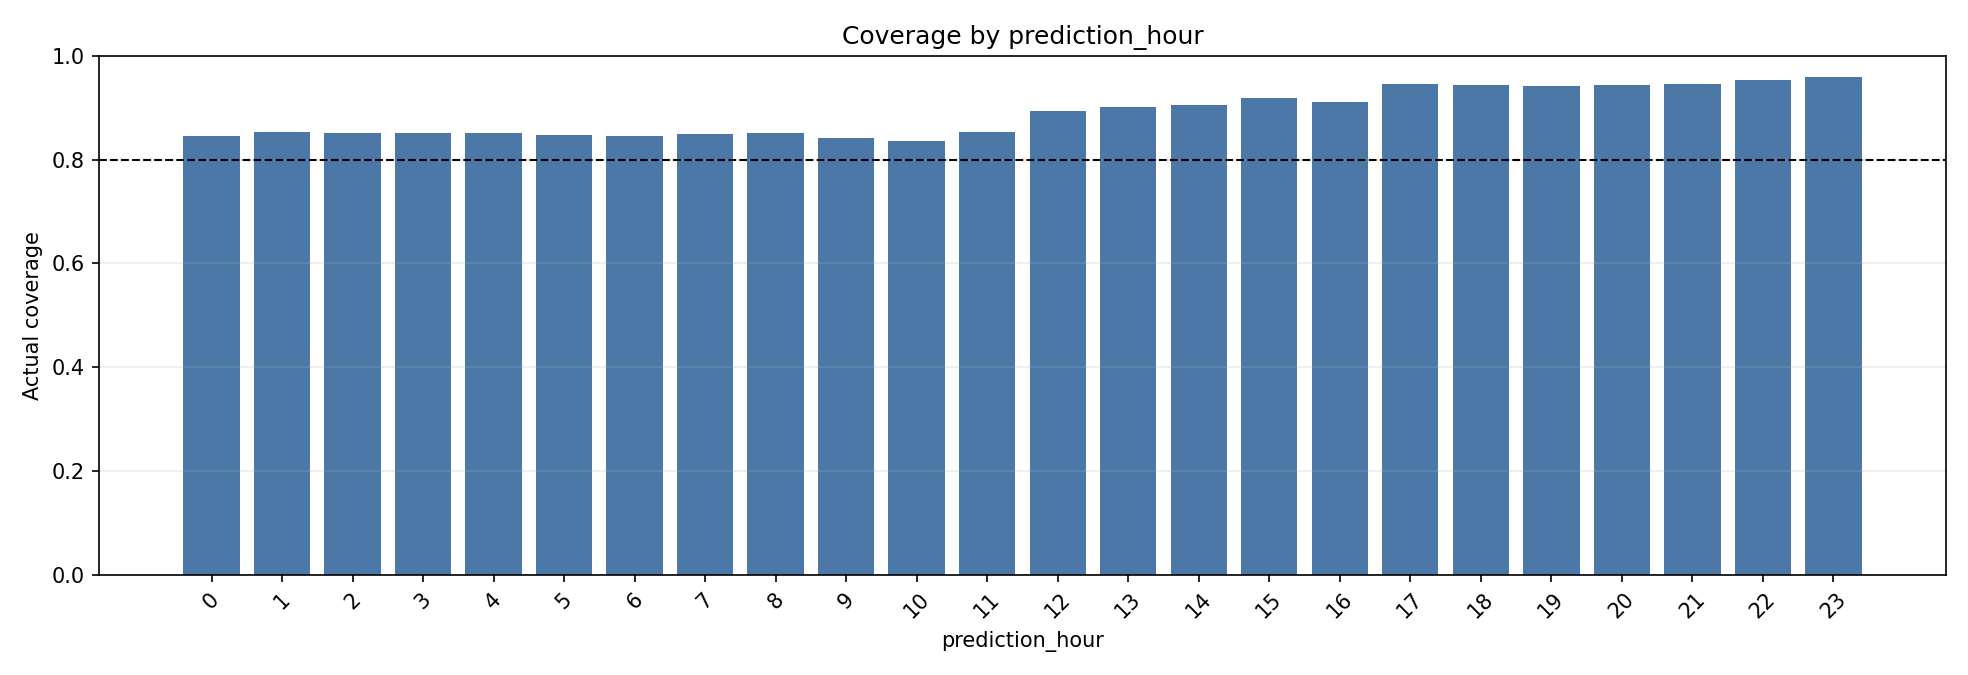

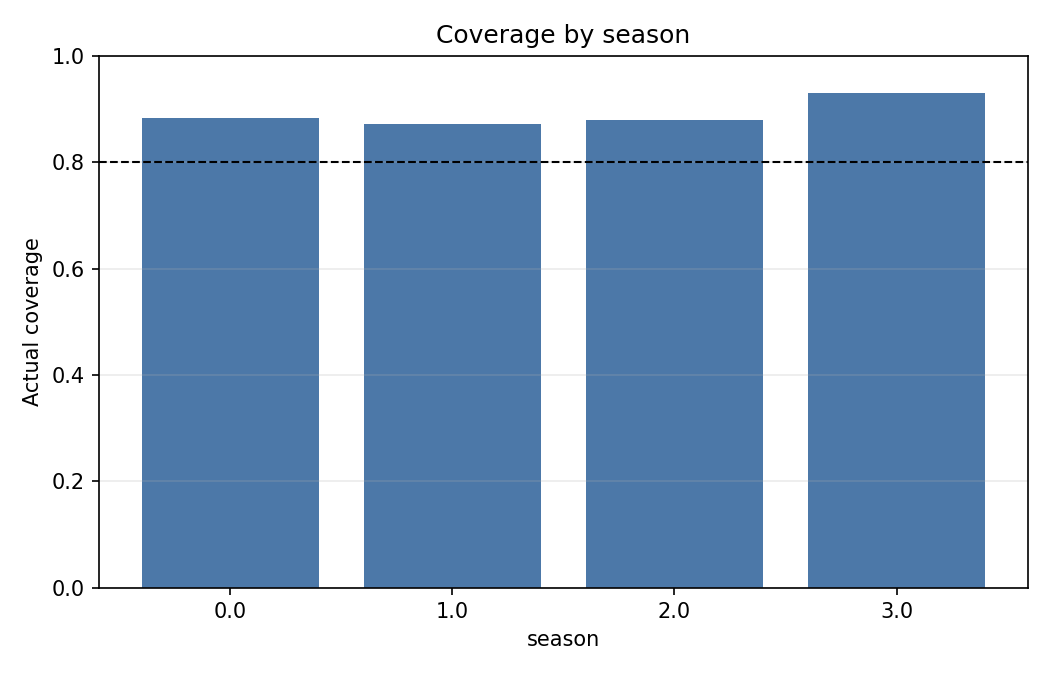

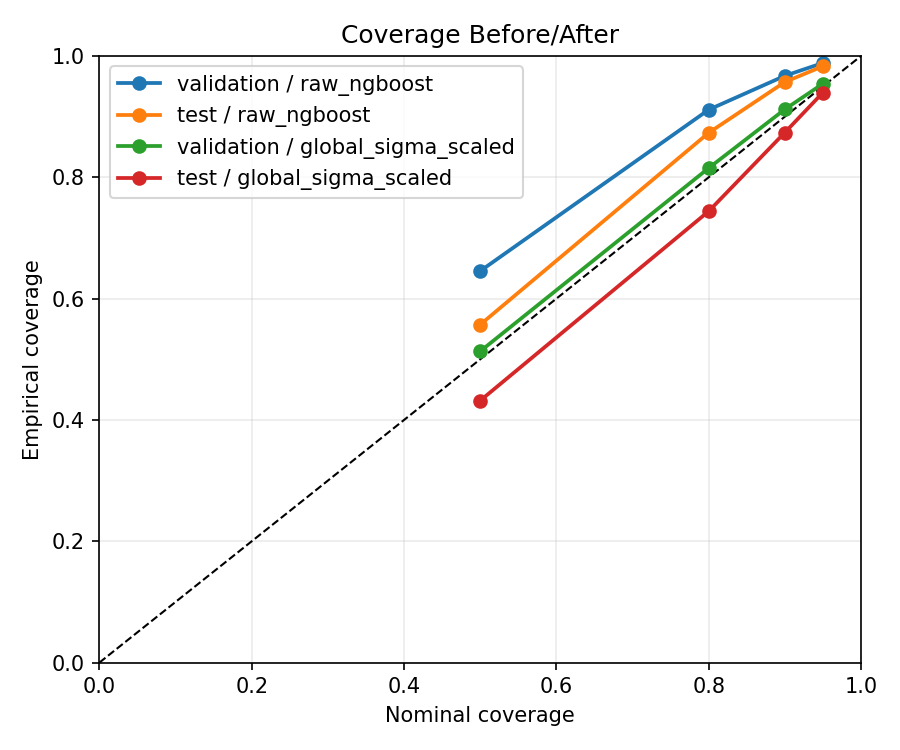

In [14]:
def show_existing_figure(rel_path):
    path = REPO_ROOT / rel_path
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Figure not found: {rel_path}")

show_existing_figure("outputs/figures/pit_histogram.png")
show_existing_figure("outputs/figures/coverage_by_hour.png")
show_existing_figure("outputs/figures/coverage_by_season.png")
show_existing_figure("outputs/figures/coverage_before_after.png")

## 8. Trading / Edge Logic

The project is not a live trading engine. The trading idea is to compare model probability with market-implied probability:

```text
edge_i = p_model_i - q_market_i
```

A positive edge is not enough by itself. Executable price, fees, bid/ask spread, slippage, liquidity, and settlement-risk handling all matter. Without timestamp-correct order-book data, this remains a research signal rather than a profitability claim.

In [15]:
edge_example = example_buckets[["bucket_name", "probability"]].copy()
edge_example = edge_example.rename(columns={"bucket_name": "bucket", "probability": "model_probability"})
offsets = np.array([-0.03, 0.02, -0.01, 0.015, -0.02, 0.025])[: len(edge_example)]
edge_example["market_probability"] = np.clip(edge_example["model_probability"].to_numpy() + offsets, 0.01, 0.99)
edge_example["edge"] = edge_example["model_probability"] - edge_example["market_probability"]
edge_example["note"] = "illustrative market price"
display(edge_example)

,bucket,model_probability,market_probability,edge,note
0,42 or lower,0.149139,0.119139,0.030,illustrative market price
1,43 to 44,0.354903,0.374903,-0.020,illustrative market price
2,45 to 46,0.349221,0.339221,0.010,illustrative market price
3,47 to 48,0.103323,0.118323,-0.015,illustrative market price
4,49 to 50,0.030570,0.010570,0.020,illustrative market price
5,51 or higher,0.012845,0.037845,-0.025,illustrative market price


## 9. UML and Pseudocode

The architecture diagram shows the full pipeline:

```text
raw data sources -> data loader -> feature builder -> model -> bucket converter -> evaluator -> edge scanner -> outputs
```

The Mermaid source is saved at `outputs/figures/project_architecture.mmd`, and a rendered presentation image is generated below.

In [16]:
architecture_mermaid = (REPO_ROOT / "outputs/figures/project_architecture.mmd").read_text(encoding="utf-8")
print(architecture_mermaid)

flowchart LR
    raw_obs[Raw hourly observations] --> loader[Data loaders]
    raw_fcst[Raw forecast data] --> loader
    loader --> targets[Target builder]
    targets --> features[Feature builder]
    features --> leakage[Leakage checks]
    leakage --> splits[Chronological split]
    splits --> model[NGBoost distribution model]
    model --> params[Distribution params: mu, sigma]
    params --> buckets[Bucket converter / CDF differencing]
    buckets --> eval[Evaluation and calibration]
    buckets --> edge[Edge scanner]
    eval --> outputs[Reports and figures]
    edge --> outputs



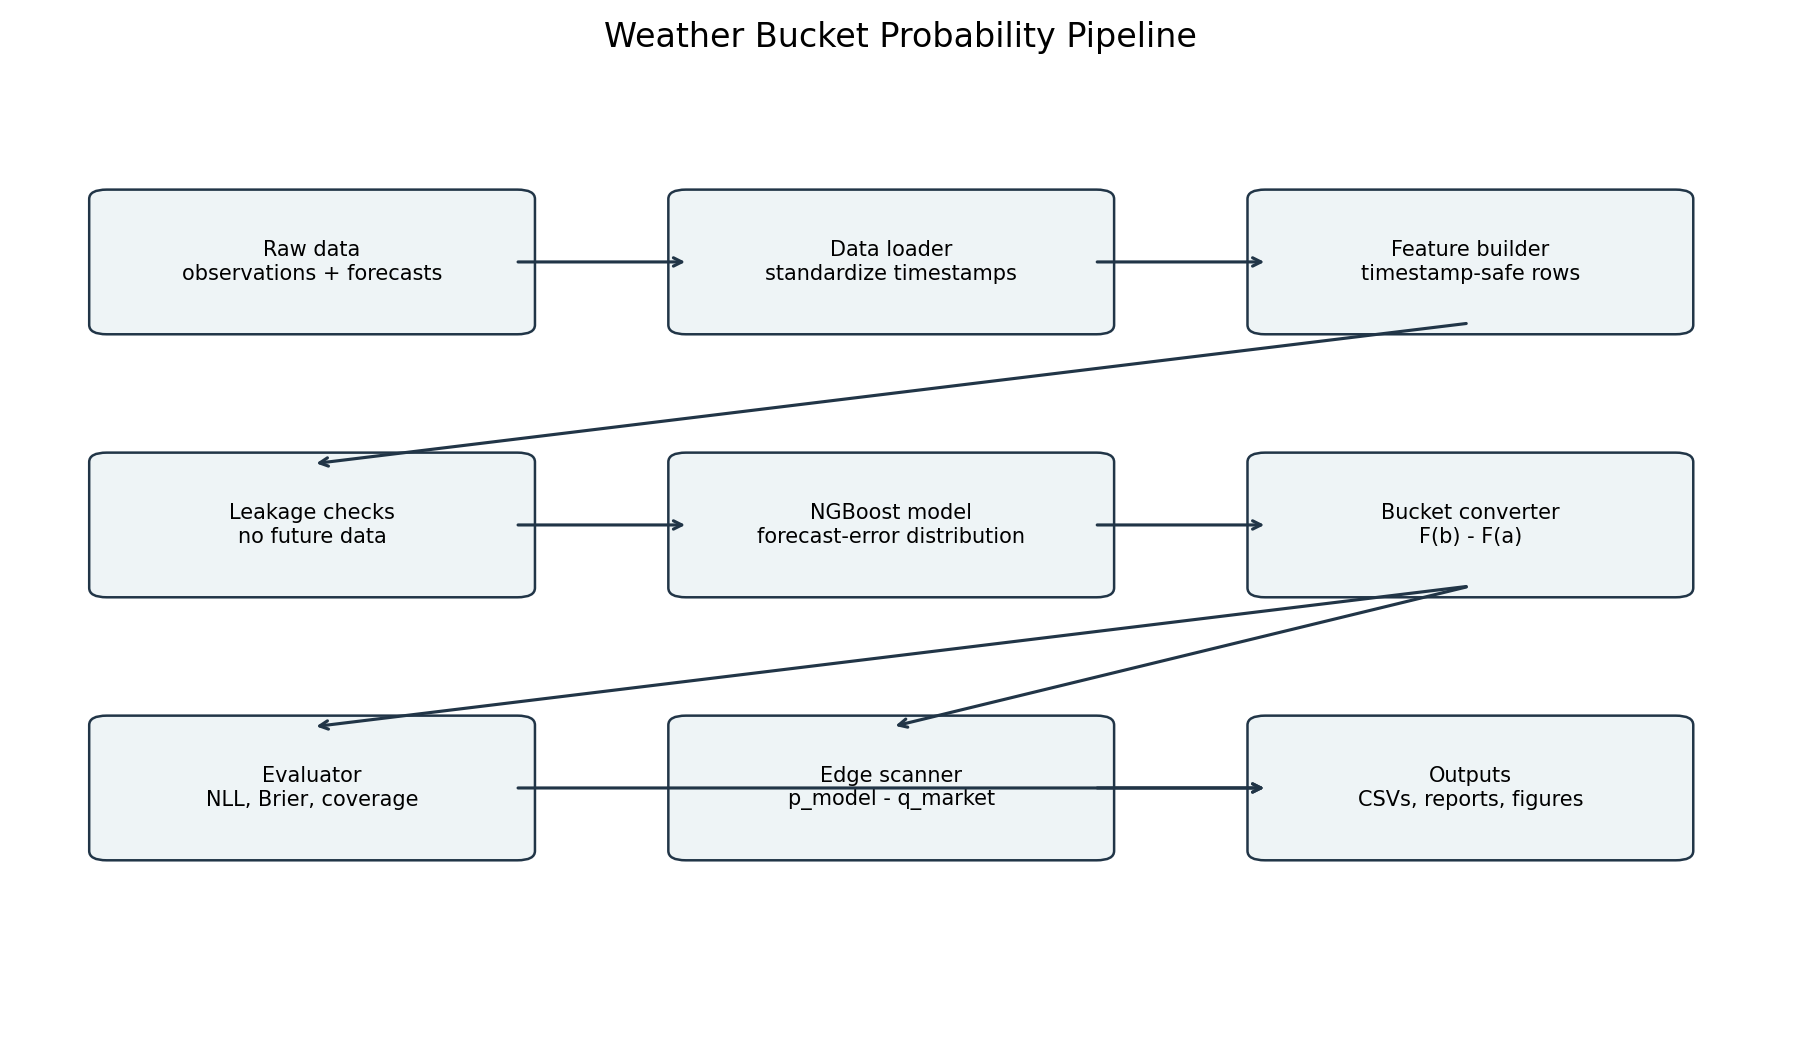

In [17]:
from matplotlib.patches import FancyBboxPatch

labels = [
    "Raw data\nobservations + forecasts",
    "Data loader\nstandardize timestamps",
    "Feature builder\ntimestamp-safe rows",
    "Leakage checks\nno future data",
    "NGBoost model\nforecast-error distribution",
    "Bucket converter\nF(b) - F(a)",
    "Evaluator\nNLL, Brier, coverage",
    "Edge scanner\np_model - q_market",
    "Outputs\nCSVs, reports, figures",
]

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")
positions = [(0.05, 0.75), (0.38, 0.75), (0.71, 0.75), (0.05, 0.47), (0.38, 0.47), (0.71, 0.47), (0.05, 0.19), (0.38, 0.19), (0.71, 0.19)]
box_w, box_h = 0.23, 0.13
for (x0, y0), label in zip(positions, labels):
    patch = FancyBboxPatch((x0, y0), box_w, box_h, boxstyle="round,pad=0.012,rounding_size=0.01", linewidth=1.2, edgecolor="#213547", facecolor="#eef4f6")
    ax.add_patch(patch)
    ax.text(x0 + box_w / 2, y0 + box_h / 2, label, ha="center", va="center", fontsize=10)

arrow_pairs = [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (5,7), (6,8), (7,8)]
for a, b in arrow_pairs:
    x1, y1 = positions[a]
    x2, y2 = positions[b]
    start = (x1 + box_w, y1 + box_h / 2) if y1 == y2 and x2 > x1 else (x1 + box_w / 2, y1)
    end = (x2, y2 + box_h / 2) if y1 == y2 and x2 > x1 else (x2 + box_w / 2, y2 + box_h)
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.5, color="#213547"))

ax.set_title("Weather Bucket Probability Pipeline", fontsize=16, pad=20)
fig.tight_layout()
arch_path = FIGURES_DIR / "project_architecture.png"
fig.savefig(arch_path, dpi=150)
plt.close(fig)
display(Image(filename=str(arch_path)))

### Full Pipeline Pseudocode

```text
load data
validate data
build timestamped features
train distribution model
predict final-high distribution
convert to bucket probabilities
compare to market prices
evaluate outputs
```

Expanded version:

```text
for each prediction timestamp:
    load observations available at or before prediction_time
    load forecasts available at or before prediction_time
    compute timestamp-safe features
    predict forecast_error distribution with NGBoost
    convert final-temperature bucket boundaries into forecast-error boundaries
    compute bucket probabilities with CDF differences
    compare model probability to market-implied probability if market data exists
    save predictions, metrics, and figures
```

## 10. Execution Demonstration

Run these commands from the repository root. Training and calibration can take longer, while this notebook uses saved outputs for a fast presentation path.

```powershell
pip install -r requirements.txt
pip install -r requirements-dev.txt
python scripts/build_features.py
python -m src.train_ngboost
python -m src.distribution_pricing
python scripts/evaluate_ngboost.py
python scripts/calibrate_ngboost.py
jupyter notebook notebooks/project_walkthrough.ipynb
```

Expected output paths:

- `data/processed/modeling_rows_v1.csv`
- `outputs/day8_features/feature_columns.json`
- `models/ngboost_normal_v0.pkl` or the configured NGBoost artifact
- `outputs/ngboost_distribution_params_v0.csv`
- `outputs/ngboost_bucket_probs_v0.csv`
- `outputs/ngboost_evaluation_report.csv`
- `outputs/ngboost_calibration_report.csv`
- `outputs/figures/`

In [18]:
expected_outputs = [
    "data/processed/modeling_rows_v1.csv",
    "outputs/day8_features/feature_columns.json",
    "outputs/final_feature_list.json",
    "outputs/ngboost_distribution_params_v0.csv",
    "outputs/ngboost_bucket_probs_v0.csv",
    "outputs/ngboost_evaluation_report.csv",
    "outputs/ngboost_calibration_report.csv",
    "outputs/figures/project_architecture.png",
    "outputs/figures/project_architecture.mmd",
]
output_check = pd.DataFrame([
    {"path": rel, "exists": (REPO_ROOT / rel).exists(), "size_bytes": (REPO_ROOT / rel).stat().st_size if (REPO_ROOT / rel).exists() else 0}
    for rel in expected_outputs
])
display(output_check)

,path,exists,size_bytes
0,data/processed/modeling_rows_v1.csv,True,24911503
1,outputs/day8_features/feature_columns.json,True,3459
2,outputs/final_feature_list.json,True,3068
3,outputs/ngboost_distribution_params_v0.csv,True,4118879
4,outputs/ngboost_bucket_probs_v0.csv,True,30407125
5,outputs/ngboost_evaluation_report.csv,True,706
6,outputs/ngboost_calibration_report.csv,True,1310
7,outputs/figures/project_architecture.png,True,98173
8,outputs/figures/project_architecture.mmd,True,593


## 11. Output Discussion

Final outputs show three different layers of the project:

1. Model distribution outputs: `mu`, `sigma`, distribution type, split, timestamp, actual high, forecast high, and forecast error.
2. Bucket probability outputs: one probability per market-style temperature bucket, derived from the distribution CDF.
3. Evaluation outputs: NLL/log loss, Brier score, calibration tables, coverage, PIT histograms, and before/after calibration diagnostics.

Important limitations:

- Hourly data may miss true intrahour highs.
- NWS settlement rules matter, including station, observation, and final settlement details.
- Rounding and temperature conversion rules can change bucket mapping.
- Market slippage, spreads, fees, and liquidity can erase apparent edge.
- Results are research signals, not guaranteed profitable trades.

In [19]:
output_examples = pd.DataFrame([
    {"output": "Distribution predictions", "path": "outputs/ngboost_distribution_params_v0.csv", "interpretation": "Forecast-error distribution per timestamp."},
    {"output": "Bucket probabilities", "path": "outputs/ngboost_bucket_probs_v0.csv", "interpretation": "Kalshi-style bucket probabilities from CDF differences."},
    {"output": "Evaluation report", "path": "outputs/ngboost_evaluation_report.csv", "interpretation": "NLL, interval log loss, Brier, coverage error, residual diagnostics."},
    {"output": "Calibration report", "path": "outputs/ngboost_calibration_report.csv", "interpretation": "Raw vs calibrated probability quality."},
    {"output": "PIT histogram", "path": "outputs/figures/pit_histogram.png", "interpretation": "Distribution calibration diagnostic."},
    {"output": "Architecture diagram", "path": "outputs/figures/project_architecture.png", "interpretation": "Presentation diagram for the pipeline."},
])
display(output_examples)

print("Example final distribution predictions")
display(params.head(3))
print("Example final bucket probabilities")
display(bucket_probs.head(12))

,output,path,interpretation
0,Distribution predictions,outputs/ngboost_distribution_params_v0.csv,Forecast-error distribution per timestamp.
1,Bucket probabilities,outputs/ngboost_bucket_probs_v0.csv,Kalshi-style bucket probabilities from CDF dif...
2,Evaluation report,outputs/ngboost_evaluation_report.csv,"NLL, interval log loss, Brier, coverage error,..."
3,Calibration report,outputs/ngboost_calibration_report.csv,Raw vs calibrated probability quality.
4,PIT histogram,outputs/figures/pit_histogram.png,Distribution calibration diagnostic.
5,Architecture diagram,outputs/figures/project_architecture.png,Presentation diagram for the pipeline.


Example final distribution predictions


,row_id,split,date,timestamp,prediction_time,prediction_timestamp,location,forecast_high,actual_high,forecast_horizon_hours,forecast_error,mu,sigma,nll,distribution_type,sigma_scale,raw_sigma
0,0,validation,2024-01-01,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,NYC,46.0,45.4,15.0,-0.6,-1.513328,1.642242,1.745357,laplace,1.3,1.263263
1,1,validation,2024-01-01,2024-01-01 01:00:00,2024-01-01 01:00:00,2024-01-01 01:00:00,NYC,46.0,45.4,14.0,-0.6,-1.670108,1.642242,1.840824,laplace,1.3,1.263263
2,2,validation,2024-01-01,2024-01-01 02:00:00,2024-01-01 02:00:00,2024-01-01 02:00:00,NYC,46.0,45.4,13.0,-0.6,-1.625249,1.645175,1.814179,laplace,1.3,1.265519


Example final bucket probabilities


,row_id,date,prediction_time,location,split,forecast_high,actual_high,forecast_error,bucket_index,bucket_name,bucket_lower_temp,bucket_upper_temp,error_lower,error_upper,mu,sigma,distribution_type,df,probability,timestamp,prediction_timestamp,forecast_horizon_hours,nll
0,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,0,42 or lower,NaN,42.5,NaN,-3.5,-1.513328,1.642242,laplace,NaN,0.149139,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
1,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,1,43 to 44,42.5,44.5,-3.5,-1.5,-1.513328,1.642242,laplace,NaN,0.354903,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
2,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,2,45 to 46,44.5,46.5,-1.5,0.5,-1.513328,1.642242,laplace,NaN,0.349221,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
3,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,3,47 to 48,46.5,48.5,0.5,2.5,-1.513328,1.642242,laplace,NaN,0.103323,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
4,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,4,49 to 50,48.5,50.5,2.5,4.5,-1.513328,1.642242,laplace,NaN,0.030570,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
5,0,2024-01-01,2024-01-01 00:00:00,NYC,validation,46.0,45.4,-0.6,5,51 or higher,50.5,NaN,4.5,NaN,-1.513328,1.642242,laplace,NaN,0.012845,2024-01-01 00:00:00,2024-01-01 00:00:00,15.0,1.745357
6,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,0,42 or lower,NaN,42.5,NaN,-3.5,-1.670108,1.642242,laplace,NaN,0.164078,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824
7,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,1,43 to 44,42.5,44.5,-3.5,-1.5,-1.670108,1.642242,laplace,NaN,0.385121,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824
8,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,2,45 to 46,44.5,46.5,-1.5,0.5,-1.670108,1.642242,laplace,NaN,0.317424,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824
9,1,2024-01-01,2024-01-01 01:00:00,NYC,validation,46.0,45.4,-0.6,3,47 to 48,46.5,48.5,0.5,2.5,-1.670108,1.642242,laplace,NaN,0.093915,2024-01-01 01:00:00,2024-01-01 01:00:00,14.0,1.840824


## Closing Takeaway

The project demonstrates how calculus, probability distributions, and machine learning connect to a market question. The model estimates a full distribution for final-high forecast error, integrates that distribution over bucket intervals, validates probability quality, and only then discusses possible trading edge.